# Compare MESA and BoOST tracks

In [1]:
from pathlib import Path
import numpy as np
import os


## get path for metisse_wrapper - added by ama
import sys
METISSE_DIR = "/home/poornima/Documents/my_METISSE_project"  
wrapper_dir = os.path.join(METISSE_DIR, "docs", "source", "notebook")
sys.path.insert(0, wrapper_dir)

import metisse_wrapper as mw



In [2]:
import pandas as pd
import glob
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import astropy.units as u
import astropy.constants as consts

### Use MESA tracks

In [3]:
run_dir = os.path.join(os.getcwd(),'run_mesa')

# Check if run_dir exists; if not, create it
os.makedirs(run_dir, exist_ok=True)

# # Delete all files inside it
folder = Path.cwd() / "run_mesa" / "output"

for file in folder.iterdir():
    if file.is_file():
        file.unlink()

In [4]:
mw.compile_metisse(METISSE_DIR, run_dir, clean=True)

In [5]:
# Paths to the precomputed stellar track libraries

metisse_params = {
    "metallicity_dir": "/home/poornima/Documents/my_METISSE_project/sample_tracks_solarZ/Hydrogen/",
    "metallicity_dir_he": "/home/poornima/Documents/my_METISSE_project/sample_tracks_solarZ/Helium/",
   
}


min_m= 10
max_m = 100.0
main_params = {
    "initial_Z": 0.02,
    "max_age": 2.0e4,
    "number_of_tracks": 10,  ## initial value was 100
    "min_mass": min_m,
    "max_mass": max_m,
    "sampling_scheme": "Uniform",
    "BHNS_mass_scheme": "Belczynski2008",
    "write_output_to_file": True,
}

In [6]:
mw.run_metisse(run_dir,main_params, metisse_params)

 program metisse_main started
 Output folder created successfully.
 program metisse_main executed


### Use BoOST tracks

In [7]:
run_dir = os.path.join(os.getcwd(),'run_BoOST')

# Check if run_dir exists; if not, create it
os.makedirs(run_dir, exist_ok=True)

# # Delete all files inside it
folder = Path.cwd() / "run_BoOST" / "output"

for file in folder.iterdir():
    if file.is_file():
        file.unlink()

In [8]:
mw.compile_metisse(METISSE_DIR, run_dir, clean=True)

In [9]:
# Paths to the precomputed stellar track libraries

metisse_params = {
    "metallicity_dir": "/home/poornima/Documents/my_METISSE_project/BoOST/",
    "metallicity_dir_he": "/home/poornima/Documents/my_METISSE_project/sample_tracks_solarZ/Helium/",
    "Z_accuracy_limit" : 2.0,  ### because for He tracks, z=0.02 and for H tracks z=0.008
}


min_m= 10
max_m = 100.0
main_params = {
    "initial_Z": 0.008,
    "max_age": 2.0e4,
    "number_of_tracks": 10,  ## initial value was 100
    "min_mass": min_m,
    "max_mass": max_m,
    "sampling_scheme": "Uniform",
    "BHNS_mass_scheme": "Belczynski2008",
    "write_output_to_file": True,
}

In [10]:
mw.run_metisse(run_dir,main_params, metisse_params)

 program metisse_main started
 Output folder created successfully.
 program metisse_main executed


### Read files

In [11]:
run_dir = os.path.join(os.getcwd(),'run_mesa')

base_name_mesa = os.path.join(run_dir, 'output')
file_name_mesa = glob.glob(base_name_mesa + "/*.dat")

num_files_mesa = len(file_name_mesa)
print(f"Number of .dat files Mesa: {num_files_mesa}")

Number of .dat files Mesa: 10


In [12]:
run_dir = os.path.join(os.getcwd(),'run_BoOST')

base_name_BoOST = os.path.join(run_dir, 'output')
file_name_BoOST = glob.glob(base_name_BoOST + "/*.dat")

num_files_BoOST = len(file_name_BoOST)
print(f"Number of .dat files BoOST: {num_files_BoOST}")

Number of .dat files BoOST: 10


### Create output images folder to save output images

In [13]:
current_path = Path.cwd()

# Create new folder inside it
output_img_dir = current_path / "output_images"
output_img_dir.mkdir(exist_ok=True)



# Hertzsprung–Russell Diagram

The HR diagram shows a star’s luminosity versus effective temperature.
Here, we visualize METISSE’s output using a Hertzsprung–Russell diagram (HRD).
The following script plots Hertzsprung–Russell diagram (HRD) from METISSE output files, color-coded by stellar mass.

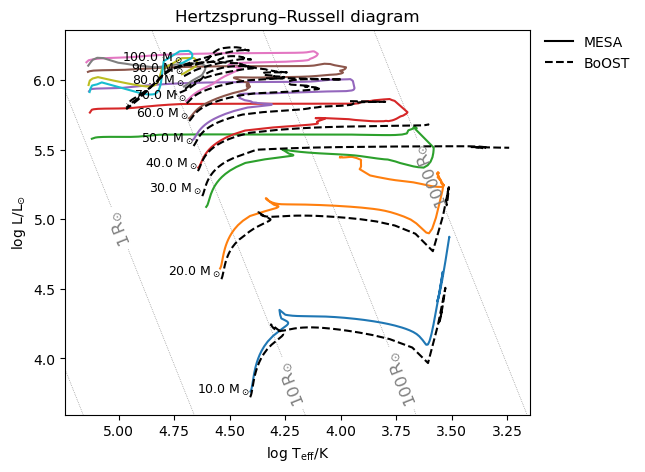

In [14]:
# --- Read all .dat track files ---
file_name_mesa.sort()
file_name_BoOST.sort()

fig, ax = plt.subplots(figsize=(6,5))
phase_lim = 5              # Limit the phases for clarity


# --- Plot each track ---
for eachfile in file_name_mesa:
    # Extract 5-digit mass value from filename (e.g., '00005' -> 5.0 Msun)
    mass = re.findall(r"[0-9]{5}", eachfile)[0]
    m = float(mass) / 100.0

    # Read stellar evolution data
    evolve_data = pd.read_table(eachfile, sep=r"\s+")
    evolve_data = evolve_data[evolve_data.phase <= phase_lim]

    Teff = evolve_data['log_Teff']
    L = evolve_data['log_L']

   

    # Plot track with color determined by mass
    ax.plot(Teff, L)

for eachfile in file_name_BoOST:
    # Extract 5-digit mass value from filename (e.g., '00005' -> 5.0 Msun)
    mass = re.findall(r"[0-9]{5}", eachfile)[0]
    m = float(mass) / 100.0

    # Read stellar evolution data
    evolve_data = pd.read_table(eachfile, sep=r"\s+")
    evolve_data = evolve_data[evolve_data.phase <= phase_lim]

    Teff = evolve_data['log_Teff']
    L = evolve_data['log_L']

   

    # Plot track with color determined by mass
    ax.plot(Teff, L, color='black', linestyle='--' )

    # Add label at the beginning of the track
    ax.text(Teff[0], L[0], f"{m:.1f} M$_\\odot$",
            fontsize=9, ha='right', va='bottom')


### add lines of constant radius using a grid of Teff and L, with the get_R_from_L_T function -------------------------------------------

def get_R_from_L_T(L, T):
    return np.sqrt(L / (4 * np.pi * consts.sigma_sb * T**4)).to(u.Rsun)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# create a range of temperatures and luminosities (and use Astropy units)
T_eff = np.logspace(xlim[0], xlim[1], 1000) * u.K
Lum = np.logspace(ylim[0], ylim[1], 1000) * u.Lsun

# turn these into a grid
L, T = np.meshgrid(Lum, T_eff)

# compute the radius for this grid and convert to solar radii
R = get_R_from_L_T(L, T)

# make a contour plot of these values
cont = ax.contour(np.log10(T.value), np.log10(L.value), np.log10(R.to(u.Rsun).value),
                    levels=[-3, -2, -1, 0, 1, 2, 3], colors="grey", zorder=1, linewidths=0.5, linestyles="dotted")

# format the labels nicely with solar radii
def fmt(x):
    if x < 0:
        return "{}".format(10**(x)) + r"$\,{\rm R_{\odot}}$"
    else:
        return "{}".format(int(np.round(10**(x)))) + r"$\,{\rm R_{\odot}}$"

# label the lines
ax.clabel(cont, fmt=fmt, use_clabeltext=True, rightside_up=True, fontsize=12)

### -------------------------------------------------------------------------------------------------------------------

legend_elements = [
    Line2D([0], [0], color='black',  linestyle='-', label='MESA'),
    Line2D([0], [0], color='black',  linestyle='--', label='BoOST')    
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),   # pushes legend outside
    borderaxespad=0,
    frameon=False
)

ax.set_xlabel(r'log T$_{\mathrm{eff}}$/K')
ax.set_ylabel(r'log L/L$_{\odot}$')
ax.invert_xaxis()
ax.set_title("Hertzsprung–Russell diagram")

img_title = "HR_diag"

save_name = output_img_dir/f"Compare_MESA_BoOST{img_title}.png"

fig.savefig(save_name, dpi=300, bbox_inches="tight")

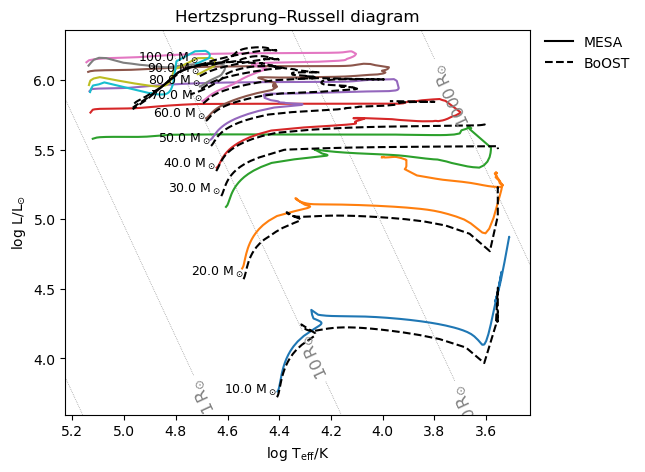

In [15]:
# --- Read all .dat track files ---
file_name_mesa.sort()
file_name_BoOST.sort()

fig, ax = plt.subplots(figsize=(6,5))
phase_lim = 5              # Limit the phases for clarity


# --- Plot each track ---
for eachfile in file_name_mesa:
    # Extract 5-digit mass value from filename (e.g., '00005' -> 5.0 Msun)
    mass = re.findall(r"[0-9]{5}", eachfile)[0]
    m = float(mass) / 100.0

    # Read stellar evolution data
    evolve_data = pd.read_table(eachfile, sep=r"\s+")
    evolve_data = evolve_data[evolve_data.phase <= phase_lim]

    Teff = evolve_data['log_Teff']
    L = evolve_data['log_L']

   

    # Plot track with color determined by mass
    ax.plot(Teff, L)

for eachfile in file_name_BoOST:
    # Extract 5-digit mass value from filename (e.g., '00005' -> 5.0 Msun)
    mass = re.findall(r"[0-9]{5}", eachfile)[0]
    m = float(mass) / 100.0

    # Read stellar evolution data
    evolve_data = pd.read_table(eachfile, sep=r"\s+")
    evolve_data = evolve_data[evolve_data.phase <= phase_lim]

    #Teff = evolve_data['log_Teff']
    L = evolve_data['log_L']

    #logTeff = 3.7617 + 0.25*logL - 0.5*logR
    Teff = 3.7617 + 0.25*evolve_data['log_L'] - 0.5*evolve_data['log_radius']

    # Plot track with color determined by mass
    ax.plot(Teff, L, color='black', linestyle='--' )

    # Add label at the beginning of the track
    ax.text(Teff[0], L[0], f"{m:.1f} M$_\\odot$",
            fontsize=9, ha='right', va='bottom')


### add lines of constant radius using a grid of Teff and L, with the get_R_from_L_T function -------------------------------------------

def get_R_from_L_T(L, T):
    return np.sqrt(L / (4 * np.pi * consts.sigma_sb * T**4)).to(u.Rsun)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# create a range of temperatures and luminosities (and use Astropy units)
T_eff = np.logspace(xlim[0], xlim[1], 1000) * u.K
Lum = np.logspace(ylim[0], ylim[1], 1000) * u.Lsun

# turn these into a grid
L, T = np.meshgrid(Lum, T_eff)

# compute the radius for this grid and convert to solar radii
R = get_R_from_L_T(L, T)

# make a contour plot of these values
cont = ax.contour(np.log10(T.value), np.log10(L.value), np.log10(R.to(u.Rsun).value),
                    levels=[-3, -2, -1, 0, 1, 2, 3], colors="grey", zorder=1, linewidths=0.5, linestyles="dotted")

# format the labels nicely with solar radii
def fmt(x):
    if x < 0:
        return "{}".format(10**(x)) + r"$\,{\rm R_{\odot}}$"
    else:
        return "{}".format(int(np.round(10**(x)))) + r"$\,{\rm R_{\odot}}$"

# label the lines
ax.clabel(cont, fmt=fmt, use_clabeltext=True, rightside_up=True, fontsize=12)

### -------------------------------------------------------------------------------------------------------------------

legend_elements = [
    Line2D([0], [0], color='black',  linestyle='-', label='MESA'),
    Line2D([0], [0], color='black',  linestyle='--', label='BoOST')    
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),   # pushes legend outside
    borderaxespad=0,
    frameon=False
)

ax.set_xlabel(r'log T$_{\mathrm{eff}}$/K')
ax.set_ylabel(r'log L/L$_{\odot}$')
ax.invert_xaxis()
ax.set_title("Hertzsprung–Russell diagram")

img_title = "HR_diag"

save_name = output_img_dir/f"Compare_MESA_BoOST_new{img_title}.png"

fig.savefig(save_name, dpi=300, bbox_inches="tight")